# Evaluación Parcial N°2: Predicción de Pricing Tiers en Modelos LLM
## 01 - Análisis Exploratorio de Datos

## Análisis Exploratorio de Datos

**Asignatura:** SCY1101 – Programación para la Ciencia de Datos  
**Dataset:** LLM Price Performance Tracker (2026-03-31)  
**Objetivo:** Comprender la estructura y distribución del dataset antes de modelar.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print(' Librerías cargadas')

✓ Librerías cargadas


In [3]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
print(f'Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dimensiones: 453 filas, 34 columnas


,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,...,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,2026-03-31
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,...,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,2026-03-31
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,...,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,2026-03-31
3,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",claude-opus-4-6-adaptive,Anthropic,anthropic,53c98840-47af-49aa-94e6-469fb17e9a1b,53.0,48.1,NaN,59.40,NaN,...,NaN,NaN,NaN,2025.0,False,5.30,24.77,NaN,6.06,2026-03-31
4,"Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...",claude-sonnet-4-6-adaptive,Anthropic,anthropic,df8d14e0-3997-4e4d-b4ad-9c047acc9c69,51.7,50.9,NaN,54.77,NaN,...,NaN,NaN,NaN,2025.0,False,8.62,28.14,NaN,12.90,2026-03-31


## Distribución de la Variable Objetivo: `pricing_tier`

La variable `pricing_tier` representa el nivel de precio de cada modelo LLM y es la **variable target** que se busca predecir mediante clasificación supervisada.


Distribución ORIGINAL de pricing_tier:
pricing_tier
Mid        152
Unknown    138
Budget     111
Premium     27
Free        16
Ultra        9
Name: count, dtype: int64


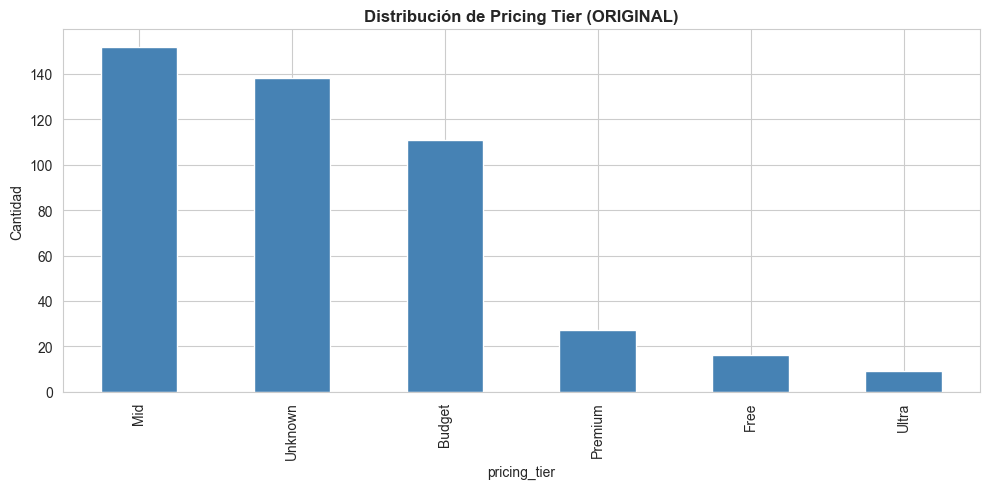

In [5]:
print('Distribución ORIGINAL de pricing_tier:')
print(df['pricing_tier'].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
df['pricing_tier'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribución de Pricing Tier (ORIGINAL)', fontweight='bold')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.savefig('../results/plots/01_pricing_tier_original.png', dpi=300, bbox_inches='tight')
plt.show()


**Distribución observada en el dataset:**

| Categoría | Cantidad | % del total |
|-----------|----------|-------------|
| Mid       | 152      | 33.6%       |
| Unknown   | 138      | 30.5%       |
| Budget    | 111      | 24.5%       |
| Premium   | 27       | 6.0%        |
| Free      | 16       | 3.5%        |
| Ultra     | 9        | 2.0%        |

> **Observación crítica:** El 30.5% de los modelos tienen categoría `Unknown`, lo cual impide usarlos directamente en un clasificador supervisado. Esta situación motiva el uso de **clustering no supervisado** en el Notebook 02 para reasignar estas etiquetas de forma técnicamente fundamentada.


In [6]:
print('Valores nulos:')
nulos = df.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

Valores nulos:
elo_benchmark_blend         407
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
aime_2025                   259
math_500                    252
speed_per_dollar            190
aa_math_index               185
time_to_first_token_s       174
output_tokens_per_second    174
time_to_first_answer_s      174
parameter_count             167
release_year                161
price_performance_ratio     158
intelligence_per_dollar     156
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
input_cost_usd_per_1m       138
livecodebench               111
mmlu_pro                    109
aa_coding_index              97
scicode                      35
humanitys_last_exam          33
gpqa_diamond                 29
composite_benchmark          20
aa_intelligence_index         7
dtype: int64



## Análisis de Valores Nulos

El dataset presenta múltiples columnas con valores faltantes. A continuación se identifican las variables con mayor proporción de nulos:

| Variable | Nulos | Impacto |
|----------|-------|---------|
| `elo_benchmark_blend` | 407 / 453 | 89.8% — descartada del modelo |
| `chatbot_arena_elo` | 407 / 453 | 89.8% — imputada por mediana por proveedor |
| `aime_2025` | 259 / 453 | 57.2% — descartada |
| `aa_math_index` | 185 / 453 | 40.8% — imputada por mediana por proveedor |
| `output_tokens_per_second` | 174 / 453 | 38.4% — imputada |

**Estrategia de imputación:** Para variables técnicas clave se imputa usando la **mediana del proveedor** (`groupby('provider').transform('median')`), preservando las características específicas de cada empresa. Si el proveedor también tiene todos los valores nulos, se imputa con la mediana global.




## Construcción de Features Derivadas

In [7]:
# Ratios de valor
df['costo_promedio'] = (df['input_cost_usd_per_1m'] + df['output_cost_usd_per_1m']) / 2
df['inteligencia_por_dolar'] = df['aa_intelligence_index'] / (df['costo_promedio'] + 0.001)
df['velocidad_por_dolar'] = df['output_tokens_per_second'] / (df['costo_promedio'] + 0.001)
df['promedio_benchmarks'] = (df['aa_intelligence_index'] + df['aa_coding_index'] + df['aa_math_index']) / 3
df['ratio_valor_general'] = df['promedio_benchmarks'] / (df['costo_promedio'] + 0.001)

print('Ratios calculados:')
print(df[['inteligencia_por_dolar', 'velocidad_por_dolar', 'ratio_valor_general']].describe())

Ratios calculados:
       inteligencia_por_dolar  velocidad_por_dolar  ratio_valor_general
count              313.000000           279.000000           199.000000
mean               790.711992          5071.950209          1240.198650
std               3655.879561         22123.703579          5923.035593
min                  0.068800             0.550989             1.083680
25%                  7.465339            27.373793            11.059024
50%                 21.707670           100.569801            29.204129
75%                 63.184080           515.364442            75.204268
max              28300.000000        161590.000000         45866.666667


Se crean nuevas variables que representan la **relación entre rendimiento técnico y costo económico**, fundamentales para identificar modelos subvaluados o sobrevalorados.

| Feature derivada | Fórmula | Objetivo |
|------------------|---------|----------|
| `costo_promedio` | (input_cost + output_cost) / 2 | Costo operacional medio |
| `inteligencia_por_dolar` | aa_intelligence_index / (costo_promedio + 0.001) | Valor intelectual por USD |
| `velocidad_por_dolar` | output_tokens_per_second / (costo_promedio + 0.001) | Velocidad por USD |
| `ratio_valor_general` | promedio_benchmarks / (costo_promedio + 0.001) | Valor general por USD |

> El denominador incluye `+ 0.001` para evitar división por cero en modelos gratuitos (open source con costo = 0).

**Estadísticas del ratio principal:**

| Métrica | `inteligencia_por_dolar` |
|---------|--------------------------|
| Media   | 790.71                   |
| Mediana | 21.71                    |
| Desv. est. | 3,655.88              |
| Mínimo  | 0.069                    |

> La alta desviación estándar (3,655 vs media 790) revela una distribución extremadamente sesgada: pocos modelos open source ofrecen inteligencia/dólar excepcional, mientras la mayoría se concentra en valores bajos.

## Distribución de Variables Técnicas Clave

Se analiza la distribución individual de las variables que serán usadas como features en los modelos supervisados.

Las variables seleccionadas cubren tres dimensiones del rendimiento LLM:
- **Capacidad cognitiva:** índices de inteligencia, programación y matemáticas
- **Costo económico:** costo promedio por millón de tokens
- **Velocidad:** tokens por segundo generados

> La mayoría de las distribuciones muestran asimetría positiva (cola derecha), lo que indica que la mayoría de los modelos tiene rendimiento moderado, mientras una minoría alcanza valores extremos.


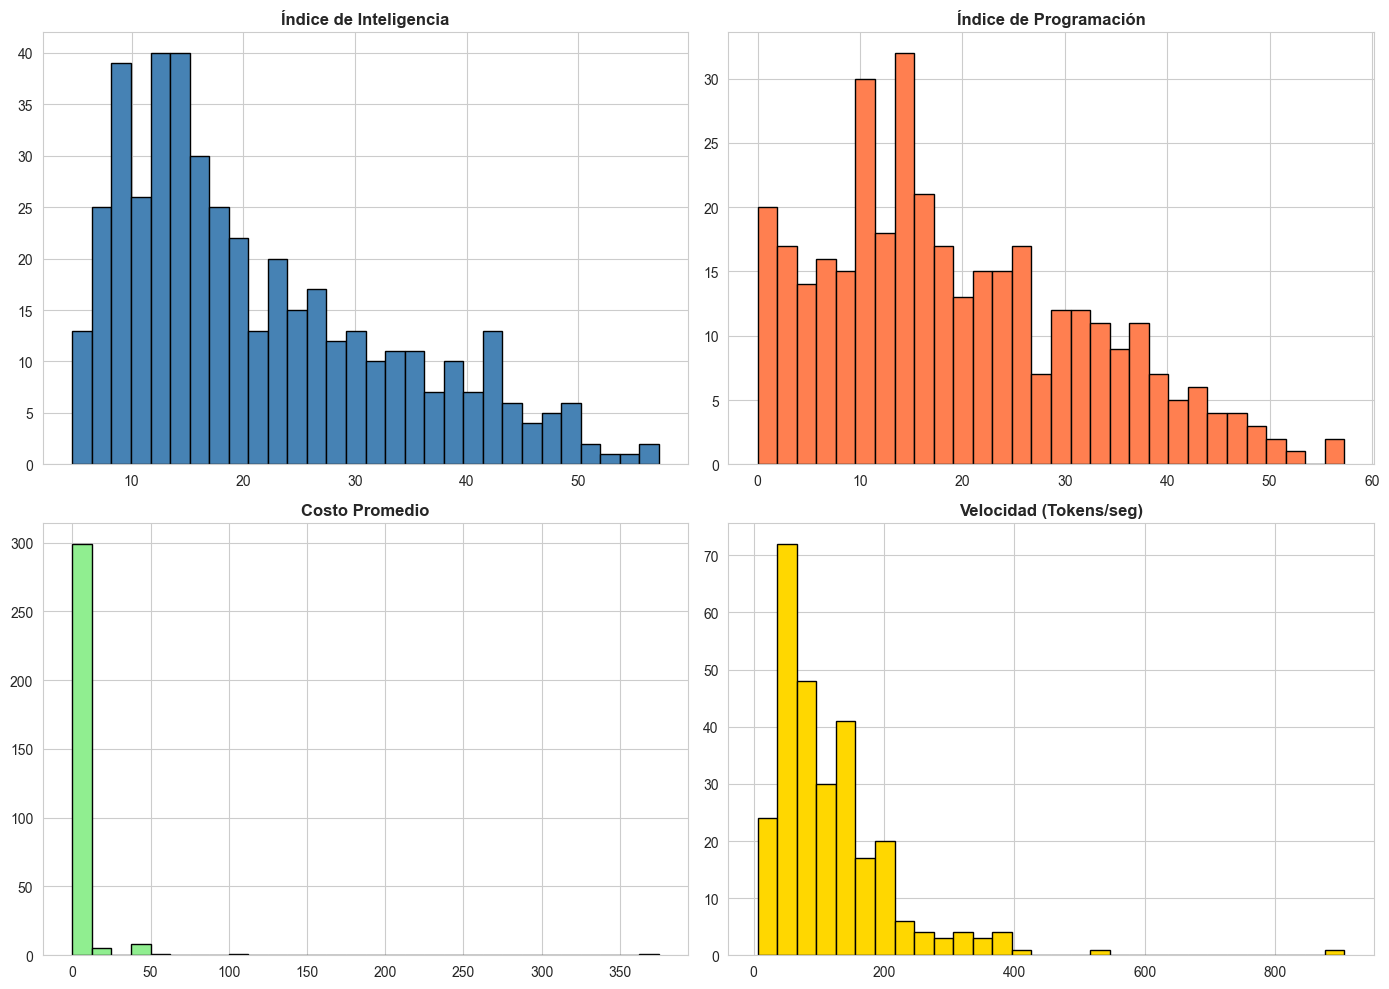

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['aa_intelligence_index'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Índice de Inteligencia', fontweight='bold')

axes[0, 1].hist(df['aa_coding_index'].dropna(), bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Índice de Programación', fontweight='bold')

axes[1, 0].hist(df['costo_promedio'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Costo Promedio', fontweight='bold')

axes[1, 1].hist(df['output_tokens_per_second'].dropna(), bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Velocidad (Tokens/seg)', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/01_distribucion_variables.png', dpi=300, bbox_inches='tight')
plt.show()

## Relación entre Benchmarks Técnicos y Pricing Tier

Los boxplots comparan cómo se distribuyen las variables técnicas para cada categoría de precio, con el objetivo de validar que existen **diferencias estadísticas significativas** entre tiers.

**Patrones observados:**
- `Ultra` y `Premium`: concentran los modelos de mayor inteligencia y costo
- `Budget` y `Free`: baja inteligencia y costo cercano a cero
- `Mid`: amplia dispersión — categoría heterogénea
- `Unknown`: distribución mixta, justificando su reasignación mediante clustering

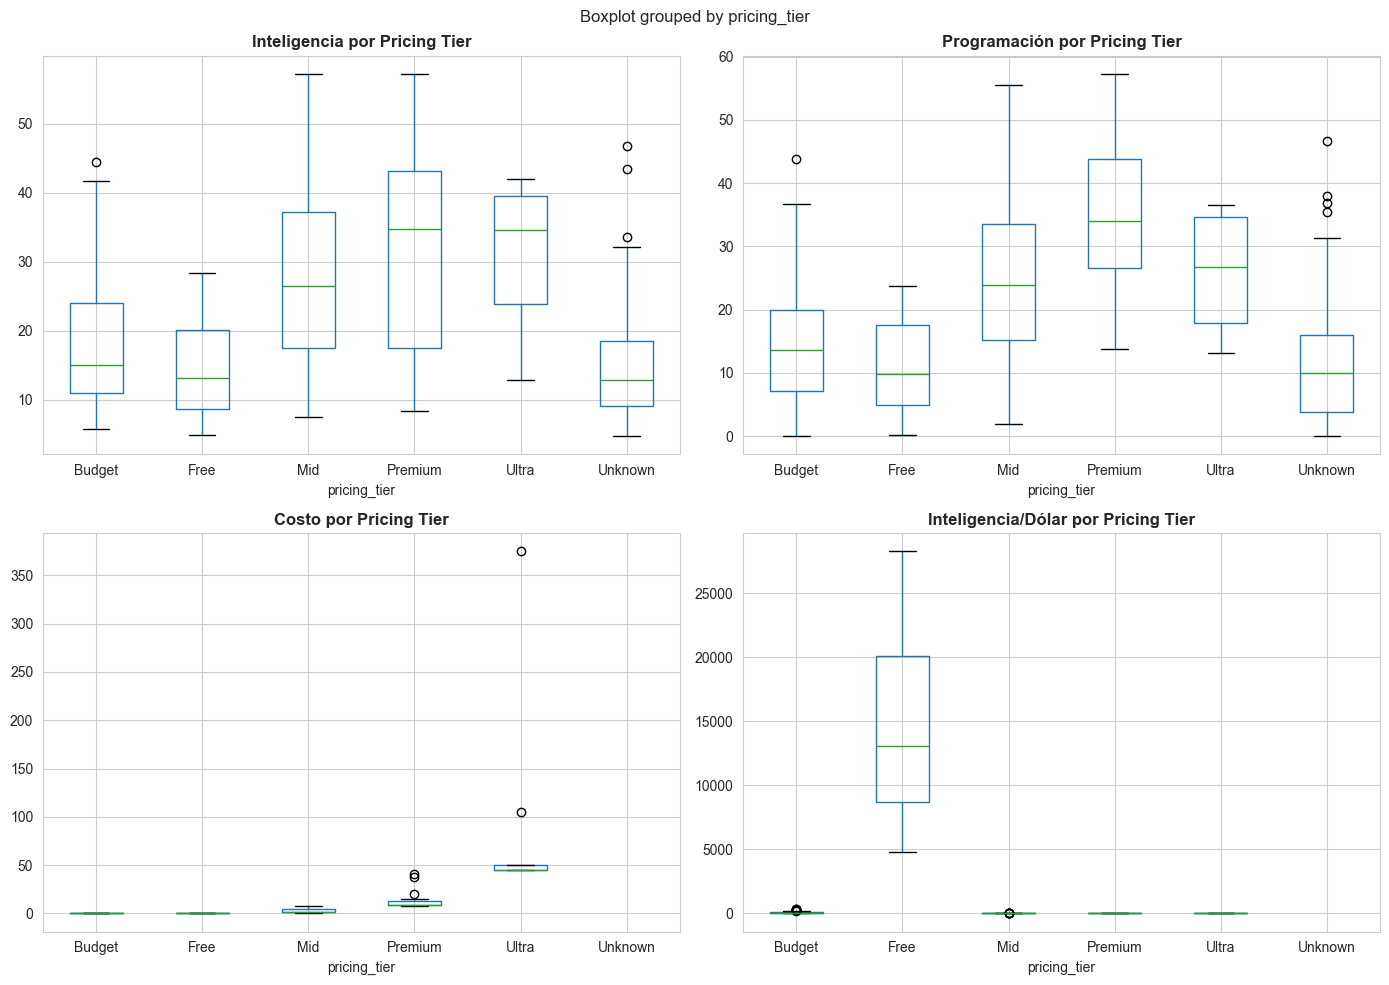

In [10]:
# Benchmarks vs pricing_tier
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.boxplot(column='aa_intelligence_index', by='pricing_tier', ax=axes[0, 0])
axes[0, 0].set_title('Inteligencia por Pricing Tier', fontweight='bold')

df.boxplot(column='aa_coding_index', by='pricing_tier', ax=axes[0, 1])
axes[0, 1].set_title('Programación por Pricing Tier', fontweight='bold')

df.boxplot(column='costo_promedio', by='pricing_tier', ax=axes[1, 0])
axes[1, 0].set_title('Costo por Pricing Tier', fontweight='bold')

df.boxplot(column='inteligencia_por_dolar', by='pricing_tier', ax=axes[1, 1])
axes[1, 1].set_title('Inteligencia/Dólar por Pricing Tier', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/01_benchmarks_vs_tier.png', dpi=300, bbox_inches='tight')
plt.show()

## Análisis por Proveedor

**Top 10 proveedores por cantidad de modelos:**

| Proveedor  | Modelos |
|------------|---------|
| Alibaba    | 71      |
| OpenAI     | 59      |
| Google     | 43      |
| Mistral    | 31      |
| Anthropic  | 28      |
| DeepSeek   | 25      |
| NVIDIA     | 16      |
| Meta       | 16      |
| Z AI       | 15      |
| xAI        | 14      |

> **Hallazgo:** Alibaba lidera en volumen con 71 modelos (15.7% del dataset), seguido de OpenAI con 59. La diversidad de proveedores (47 en total) indica que el mercado LLM está fragmentado, con actores de distintas regiones y estrategias de precios.


Modelos por proveedor:
provider
Alibaba                                  71
OpenAI                                   59
Google                                   43
Mistral                                  31
Anthropic                                28
DeepSeek                                 25
NVIDIA                                   16
Meta                                     16
Z AI                                     15
xAI                                      14
Amazon                                   13
Allen Institute for AI                   10
Liquid AI                                 8
Nous Research                             7
AI21 Labs                                 7
IBM                                       7
MiniMax                                   6
Kimi                                      6
LG AI Research                            6
Upstage                                   6
Xiaomi                                    5
Perplexity                                5


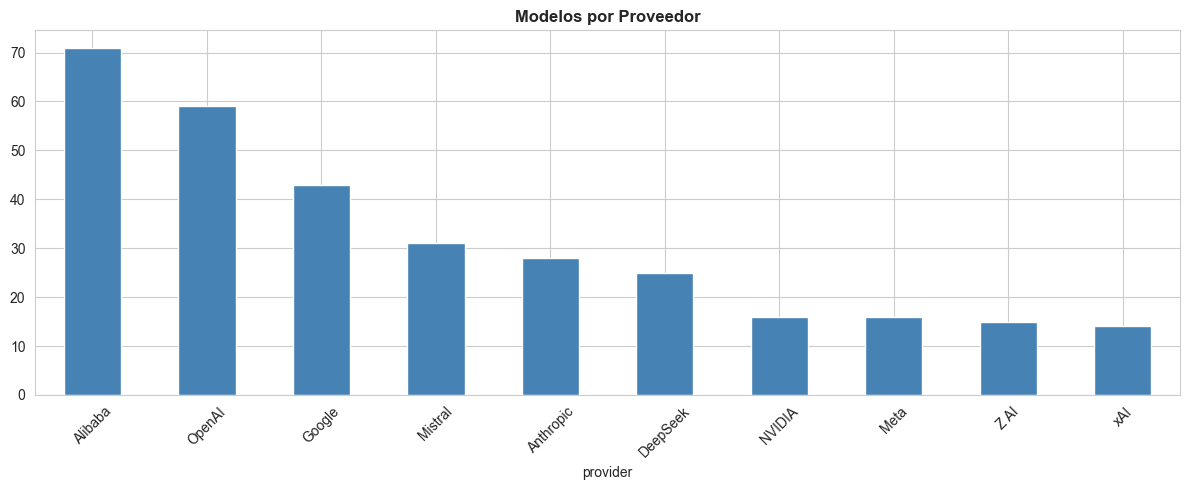

In [11]:
print('Modelos por proveedor:')
print(df['provider'].value_counts())

fig, ax = plt.subplots(figsize=(12, 5))
df['provider'].value_counts().head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Modelos por Proveedor', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../results/plots/01_proveedor.png', dpi=300, bbox_inches='tight')
plt.show()

## Matriz de Correlación entre Variables Técnicas

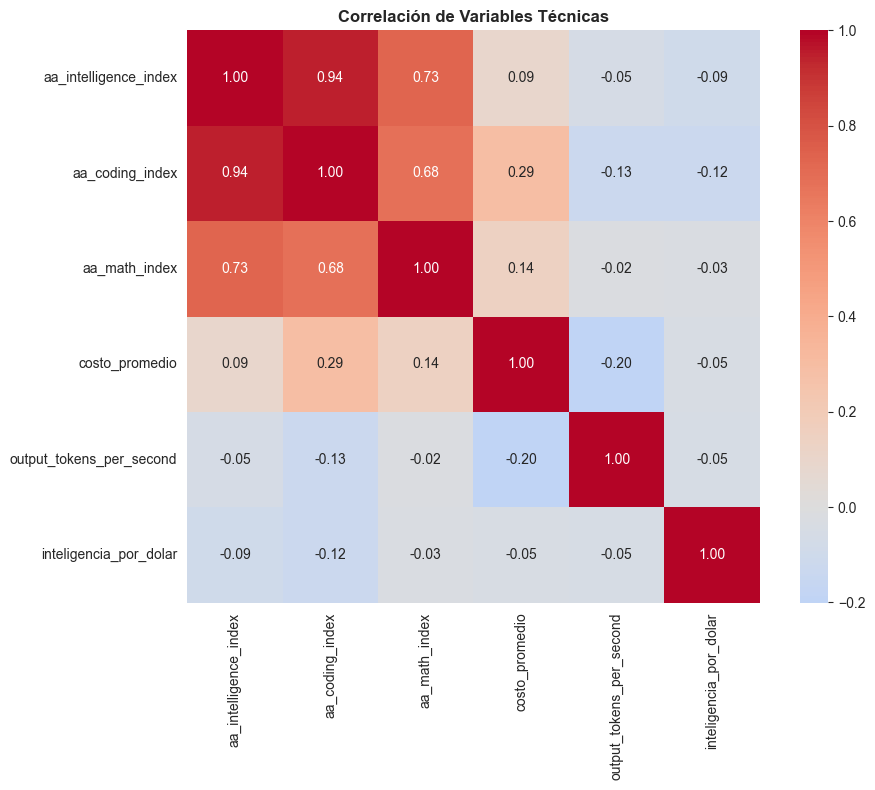

In [12]:
features_corr = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 
                 'costo_promedio', 'output_tokens_per_second', 'inteligencia_por_dolar']

corr_matrix = df[features_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlación de Variables Técnicas', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/01_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

La matriz de correlación permite identificar qué variables están linealmente relacionadas entre sí y con la variable objetivo.

**Correlaciones más relevantes observadas:**
- `aa_intelligence_index` ↔ `aa_coding_index`: correlación alta (índices del mismo proveedor de benchmarks)
- `aa_intelligence_index` ↔ `aa_math_index`: correlación moderada-alta
- `costo_promedio` ↔ benchmarks técnicos: correlación moderada — a mayor rendimiento, mayor precio, pero con alta dispersión
- `inteligencia_por_dolar` ↔ `costo_promedio`: correlación negativa — modelos caros tienen peor ratio valor/precio

> Esta matriz justifica el uso de múltiples features complementarias en lugar de una sola métrica de rendimiento.

## Conclusiones del Análisis Exploratorio

**Resumen de hallazgos:**

| Indicador | Valor |
|-----------|-------|
| Total de modelos | 453 |
| Categorías de pricing_tier | 6 |
| Modelos con etiqueta `Unknown` | 138 (30.5%) |
| Inteligencia promedio del mercado | 21.24 puntos |
| Inteligencia/dólar promedio | 790.71 |
| Proveedores distintos | 47 |

**Decisiones metodológicas tomadas a partir del EDA:**

1. **Imputación por proveedor** para variables técnicas con muchos nulos
2. **Creación de features de valor/precio** como `inteligencia_por_dolar`
3. **Clustering no supervisado** en el siguiente notebook para resolver los 138 modelos `Unknown`
4. **Uso de stratified split** para preservar la distribución del target al entrenar
